### Project Summary

This EDA project analyzes Acme Co.'s USA sales data (2014–2018) to understand sales performance and business trends. The analysis includes data cleaning, sales exploration, trend analysis, and customer segmentation. Insights obtained are used to support business decision-making and dashboard creation.



### Problem Statement

Organizations need to understand the factors influencing sales and profitability. This project analyzes historical sales data to identify key trends, performance drivers, and business opportunities across products, channels, and regions.



### Objective

The objective of this project is to extract actionable insights from sales data. It focuses on identifying top-performing areas, analyzing sales trends, and supporting data-driven business decisions through visualization and reporting.

SetUp, Configuration

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure notebook display
%matplotlib inline
sns.set_style("whitegrid")    # clean seaborn style
plt.rcParams['figure.figsize'] = (10, 6)   # default fig size

Data Loading

In [2]:
# Read all sheets
sheets = pd.read_excel(
    "Regional Sales Dataset.xlsx",
    sheet_name=None
)

# Assign DataFrames
df_sales      = sheets["Sales Orders"]
df_customers  = sheets["Customers"]
df_products   = sheets["Products"]
df_regions    = sheets["Regions"]
df_state_reg  = sheets["State Regions"]
df_budgets    = sheets["2017 Budgets"]

In [3]:
print(f"df_sales shape:{df_sales.shape}")   # Sales Orders

df_sales shape:(64104, 12)


In [4]:
print(f"df_customers shape:{df_customers.shape}")     # Customers


df_customers shape:(175, 2)


In [5]:
print(f"df_products shape:{df_products.shape}")   # Products

df_products shape:(30, 2)


In [6]:
print(f"df_regions shape:{df_regions.shape}")   # Regions

df_regions shape:(994, 15)


In [7]:
print(f"df_state_reg shape:{df_state_reg.shape}")    # State Regions

df_state_reg shape:(48, 3)


In [8]:
print(f"df_budgets shape:{df_budgets.shape} ")     # 2017 Budgets

df_budgets shape:(30, 2) 


Data Exploration

In [9]:
df_sales.head(4)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852


In [10]:
df_customers.head(4)

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp


In [11]:
df_products.head(4)

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4


In [12]:
df_regions.head(4)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago


In [13]:
df_state_reg.head(4)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West


In [14]:
df_budgets.head(4)

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824


In [15]:
# # Set the first row as the header
# new_header = df_state_reg.iloc[0]
# df_state_reg.columns = new_header

# # Remove the header row from the data
# df_state_reg = df_state_reg.iloc[1:].reset_index(drop=True)

# # Verify
# print(df_state_reg.columns.tolist())

In [16]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [17]:
len(df_sales) == len(df_sales.drop_duplicates()) #checking duplicates

True

Data Cleaning & Wrangling

In [18]:
# Merge with Customers
df = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

In [19]:
df.head(4)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group


In [20]:
# Merge with Products
df = df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)


In [21]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [22]:
# Merge with Regions
df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)

In [23]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [24]:
# Merge with State Regions
df = df.merge(
    df_state_reg[["State Code", "Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code'
)

In [25]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [26]:
# Merge with Budgets
df = df.merge(
    df_budgets,
    how='left',
    on='Product Name'
)

In [27]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [28]:
df.to_csv("checking_btw_cleaning.csv")

In [29]:
# Customer Index
# Index
# id
# State Code

# CleanUp redundant columns
cols_to_drop=['Customer Index', 'Index', 'id', 'State Code']
df=df.drop(columns=cols_to_drop, errors='ignore')

df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [30]:
#Convert all columns to lowercase for consistency and easier access
df.columns = df.columns.str.lower()
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [31]:
#Keep the important columns and delete the columns we dont need 

cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'
]

In [32]:
df = df[cols_to_keep]
df.head()

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [33]:
# Renaming the columns
df =df.rename(columns={
    'ordernumber' : 'order_number',
    'orderdate' : 'order_date',
    'customer names' : 'customer_name',
    'product name' : 'product_name',
    'order quantity' : 'order_quantity',
    'unit price' : 'unit_price',
    'line total' : 'revenue',
    'total_unit_cost' : 'cost',
    'state_code' : 'state',
    'state' : 'state_name',
    'latitude' : 'lat',
    'longitude' : 'lon',
    '2017 budgets' : 'budget'
})

df.head(3)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270


In [34]:
#Blank out budgets for non-2017 orders
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

df[['order_date','product_name', 'revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [35]:
df[['order_date','product_name', 'revenue','budget']].tail(5)

,order_date,product_name,revenue,budget
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN
64103,2018-02-28,Product 15,7986.4,NaN


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   customer_name    64104 non-null  object        
 3   channel          64104 non-null  object        
 4   product_name     64104 non-null  object        
 5   order_quantity   64104 non-null  int64         
 6   unit_price       64104 non-null  float64       
 7   revenue          64104 non-null  float64       
 8   total unit cost  64104 non-null  float64       
 9   state            64104 non-null  object        
 10  county           64104 non-null  object        
 11  state_name       64104 non-null  object        
 12  region           64104 non-null  object        
 13  lat              64104 non-null  float64       
 14  lon              64104 non-null  float

In [37]:
#filter the dataset to include only records from year 2017
df_2017 = df[df['order_date'].dt.year == 2017]

In [38]:
# Check for missing values in each column of the dataset
df.isnull().sum()

order_number           0
order_date             0
customer_name          0
channel                0
product_name           0
order_quantity         0
unit_price             0
revenue                0
total unit cost        0
state                  0
county                 0
state_name             0
region                 0
lat                    0
lon                    0
budget             48841
dtype: int64

In [39]:
df['order_month_num'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.strftime('%b')  

In [40]:
df.to_csv("Regional_Sales_Cleaned.csv", index=False)

Feature Engineering

In [41]:
df['total_cost'] = df['order_quantity'] * df['total unit cost']

In [42]:
df['profit'] = df['revenue'] -df['total_cost']
df['profit_margin_%'] = df['profit'] / df['revenue'] * 100

In [43]:
df.head(3)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,...,state_name,region,lat,lon,budget,order_month_num,order_month_name,total_cost,profit,profit_margin_%
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,Georgia,South,32.08354,-81.09983,NaN,1,Jan,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Indiana,Midwest,39.61366,-86.10665,NaN,1,Jan,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,California,West,37.66243,-121.87468,NaN,1,Jan,4108.440,1760.760,30.0


Exploratory Data Analysis(EDA)

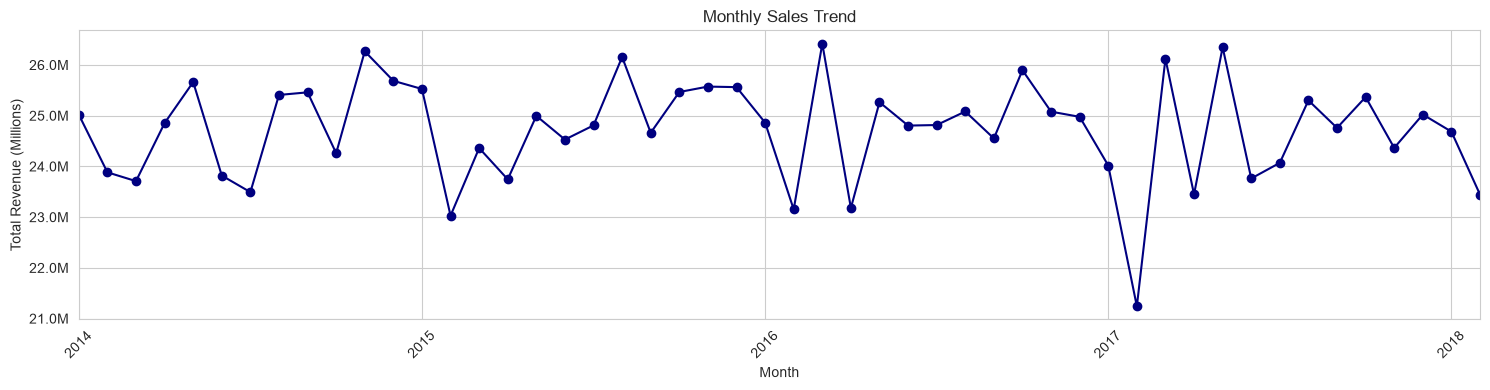

In [44]:
df['order_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(15,4))

monthly_sales.plot(marker='o', color='navy')

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [45]:
df_ = df[df['order_date'].dt.year != 2018]  

monthly_sales = (
    df_
    .groupby(['order_month_num', 'order_month_name'])['revenue']
    .sum()
    .sort_index()
    )


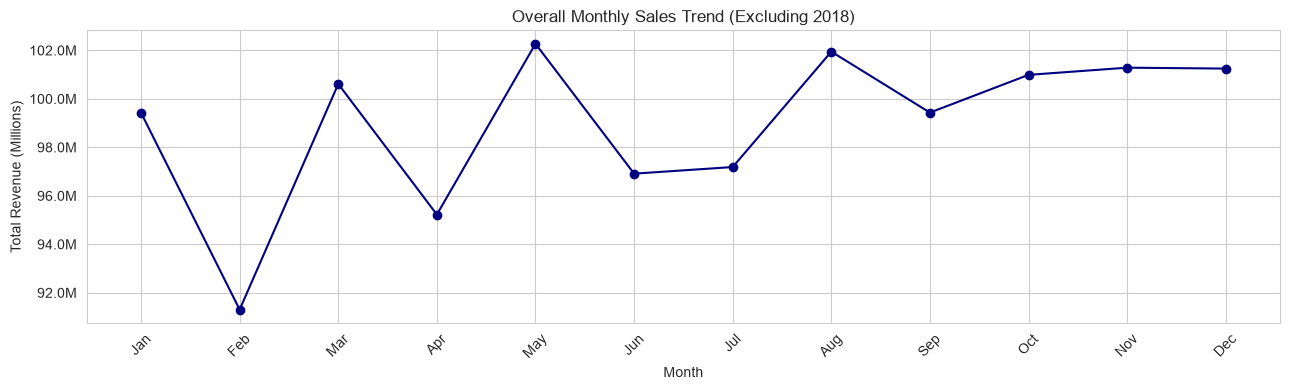

In [46]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13, 4))
plt.plot(
    monthly_sales.index.get_level_values(1),  
    monthly_sales.values,                    
    marker='o',                               
    color='navy'                              
)

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Overall Monthly Sales Trend (Excluding 2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

C:\Users\rsind\AppData\Local\Temp\ipykernel_1756\532264481.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


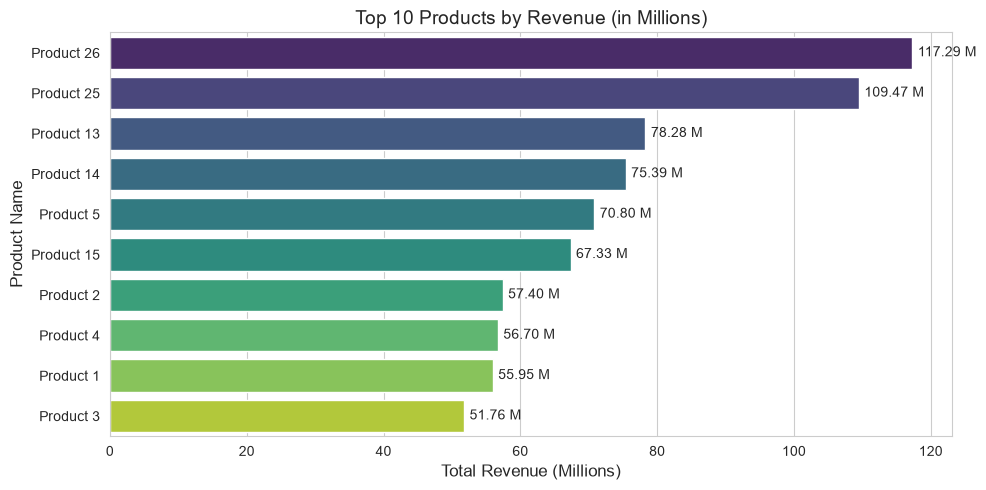

In [47]:
# Top 10 Products by Revenue

top_prod = (
    df.groupby('product_name')['revenue']
      .sum()
      .div(1_000_000)      
      .nlargest(10)
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=top_prod.values,
    y=top_prod.index,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f M',
        padding=4,
        fontsize=10
    )

plt.title('Top 10 Products by Revenue (in Millions)', fontsize=14)
plt.xlabel('Total Revenue (Millions)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\rsind\AppData\Local\Temp\ipykernel_1756\279013983.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


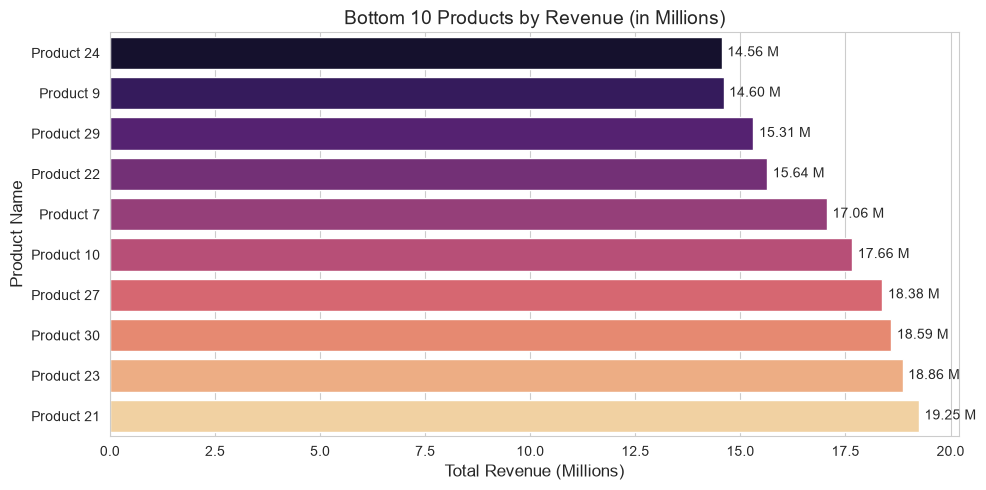

In [48]:
# Bottom 10 Products by Revenue

bottom_prod = (
    df.groupby('product_name')['revenue']
      .sum()
      .div(1_000_000)
      .nsmallest(10)
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=bottom_prod.values,
    y=bottom_prod.index,
    palette='magma'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f M',
        padding=4,
        fontsize=10
    )

plt.title('Bottom 10 Products by Revenue (in Millions)', fontsize=14)
plt.xlabel('Total Revenue (Millions)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\rsind\AppData\Local\Temp\ipykernel_1756\3754769555.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


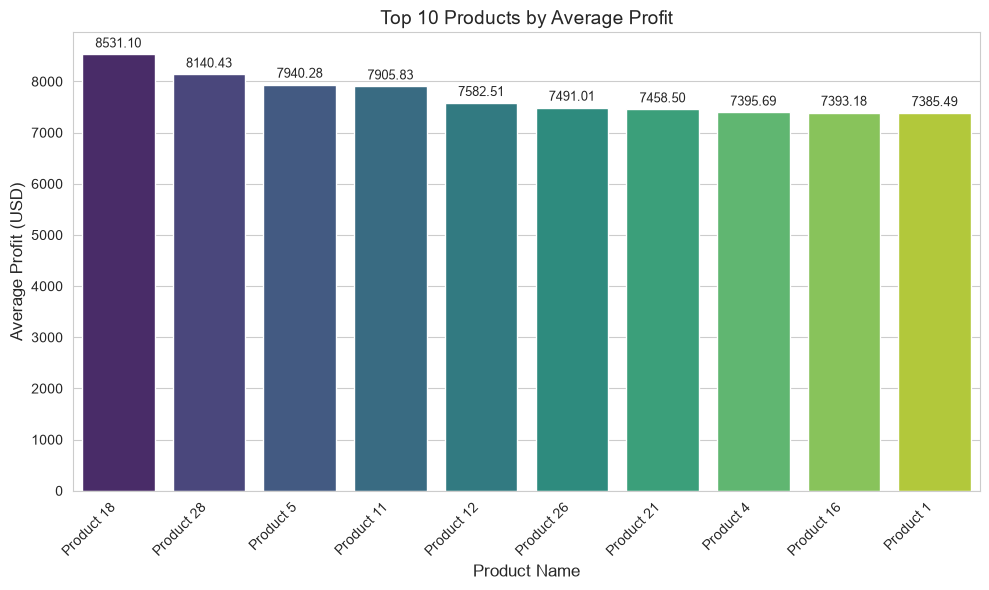

In [49]:
# Compute average profit per product and select the top 10
top_margin = (
    df.groupby('product_name')['profit']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top_margin.index,
    y=top_margin.values,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3,
        fontsize=9
    )

plt.title('Top 10 Products by Average Profit', fontsize=14)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Average Profit (USD)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

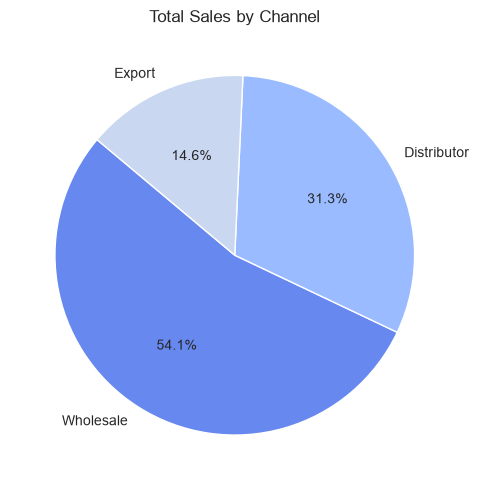

In [50]:
# Group revenue by sales channel and sort descending
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(5, 5))

plt.pie(
    chan_sales.values,                 
    labels=chan_sales.index,        
    autopct='%1.1f%%',                  
    startangle=140,                    
    colors=sns.color_palette('coolwarm')
)

plt.title('Total Sales by Channel')

plt.tight_layout()

# Display the chart
plt.show()

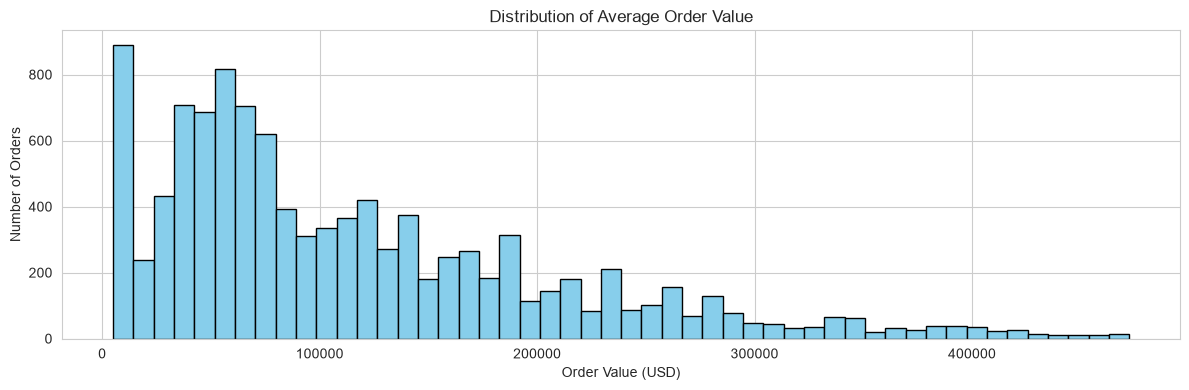

In [51]:
# Calculate the total revenue for each order to get the order value
aov = df.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(12, 4))

plt.hist(
    aov,              
    bins=50,         
    color='skyblue',  
    edgecolor='black'  
)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')

plt.tight_layout()

plt.show()

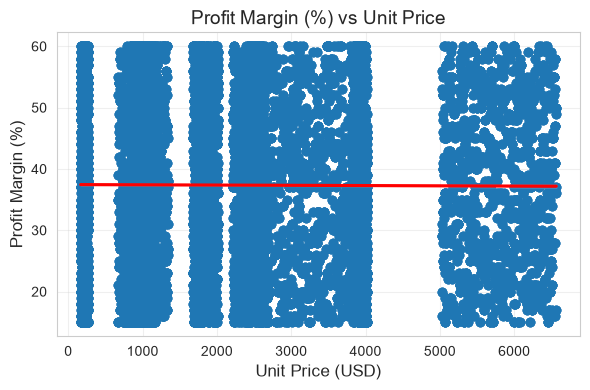

In [52]:
plt.figure(figsize=(6, 4))

sns.regplot(
    data=df,
    x='unit_price',
    y='profit_margin_%',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title('Profit Margin (%) vs Unit Price', fontsize=14)
plt.xlabel('Unit Price (USD)', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

C:\Users\rsind\AppData\Local\Temp\ipykernel_1756\4014401271.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


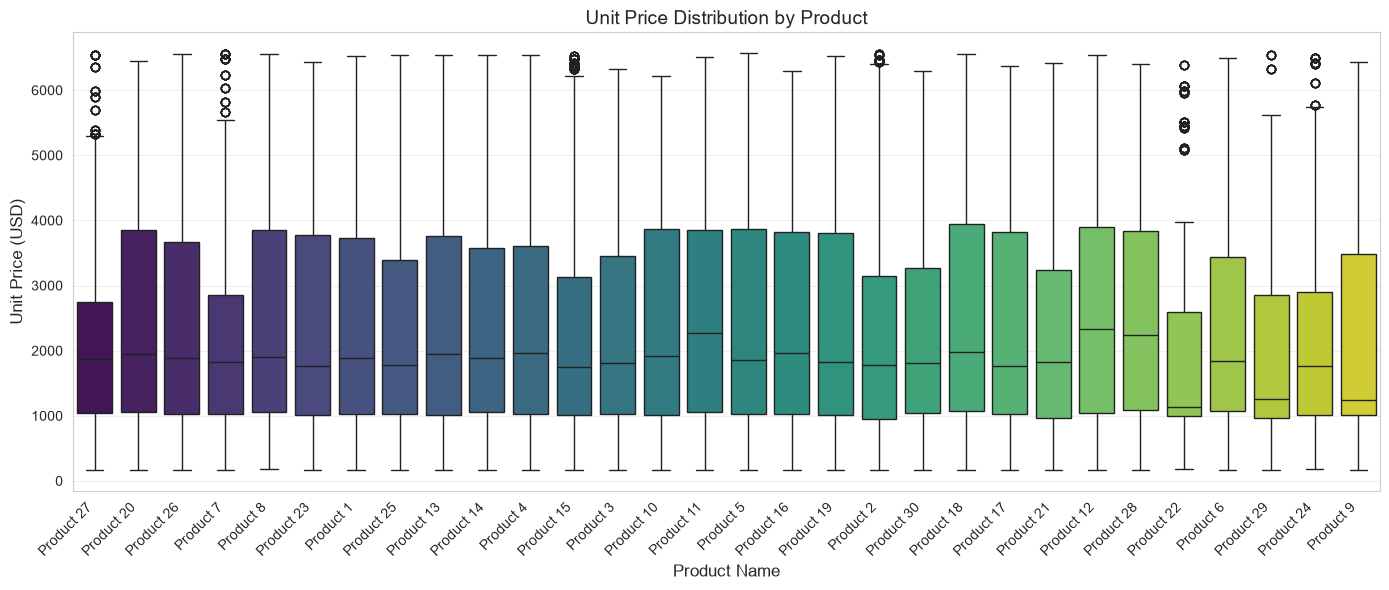

In [53]:
# Unit Price Distribution by Product

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='product_name',
    y='unit_price',
    palette='viridis'
)

plt.title('Unit Price Distribution by Product', fontsize=14)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Unit Price (USD)', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\rsind\AppData\Local\Temp\ipykernel_1756\1274084495.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
C:\Users\rsind\AppData\Local\Temp\ipykernel_1756\1274084495.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


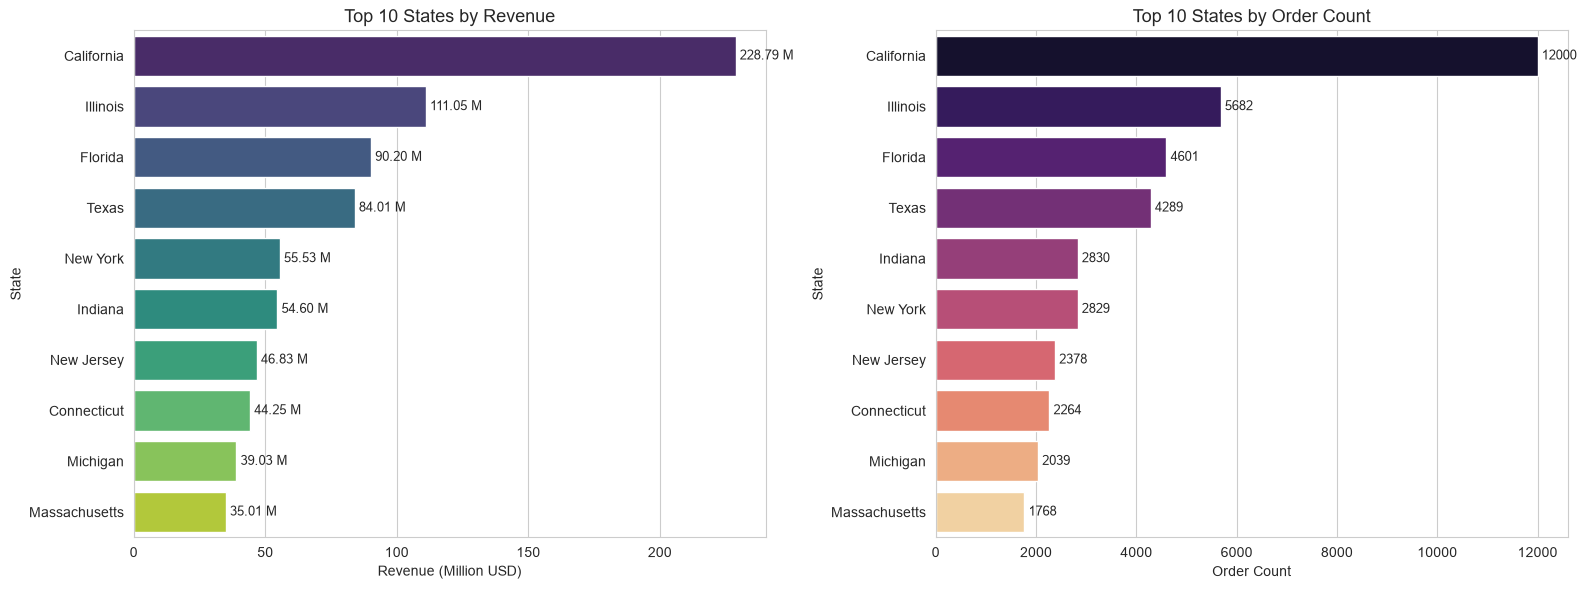

In [54]:
# Top 10 States by Revenue & Order Count

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------
# Top 10 States by Revenue
# -------------------------------
top_states_rev = (
    df.groupby('state_name')['revenue']
      .sum()
      .div(1_000_000)          # Convert to Millions
      .nlargest(10)
)

ax1 = sns.barplot(
    x=top_states_rev.values,
    y=top_states_rev.index,
    palette='viridis',
    ax=axes[0]
)

for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%.2f M',
        padding=3,
        fontsize=9
    )

ax1.set_title('Top 10 States by Revenue', fontsize=13)
ax1.set_xlabel('Revenue (Million USD)')
ax1.set_ylabel('State')


# -------------------------------
# Top 10 States by Order Count
# -------------------------------
top_states_orders = (
    df.groupby('state_name')['order_number']
      .count()
      .nlargest(10)
)

ax2 = sns.barplot(
    x=top_states_orders.values,
    y=top_states_orders.index,
    palette='magma',
    ax=axes[1]
)

for container in ax2.containers:
    ax2.bar_label(
        container,
        padding=3,
        fontsize=9
    )

ax2.set_title('Top 10 States by Order Count', fontsize=13)
ax2.set_xlabel('Order Count')
ax2.set_ylabel('State')

plt.tight_layout()
plt.show()

C:\Users\rsind\AppData\Local\Temp\ipykernel_1756\1645676871.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


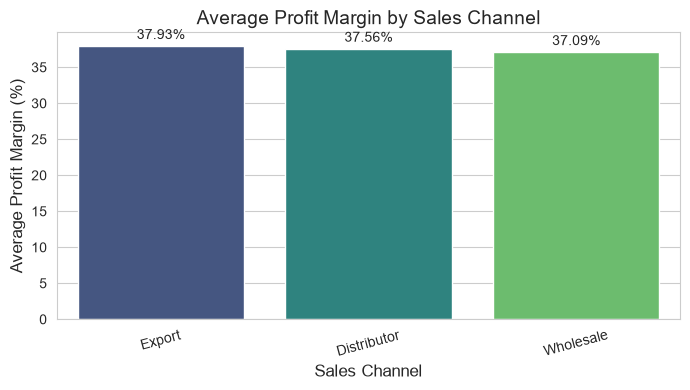

In [55]:
# Average Profit Margin (%) by Sales Channel

avg_margin = (
    df.groupby('channel')['profit_margin_%']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    x=avg_margin.index,
    y=avg_margin.values,
    palette='viridis'
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=10
    )

plt.title('Average Profit Margin by Sales Channel', fontsize=14)
plt.xlabel('Sales Channel', fontsize=12)
plt.ylabel('Average Profit Margin (%)', fontsize=12)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

C:\Users\rsind\AppData\Local\Temp\ipykernel_1756\2549344213.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
C:\Users\rsind\AppData\Local\Temp\ipykernel_1756\2549344213.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


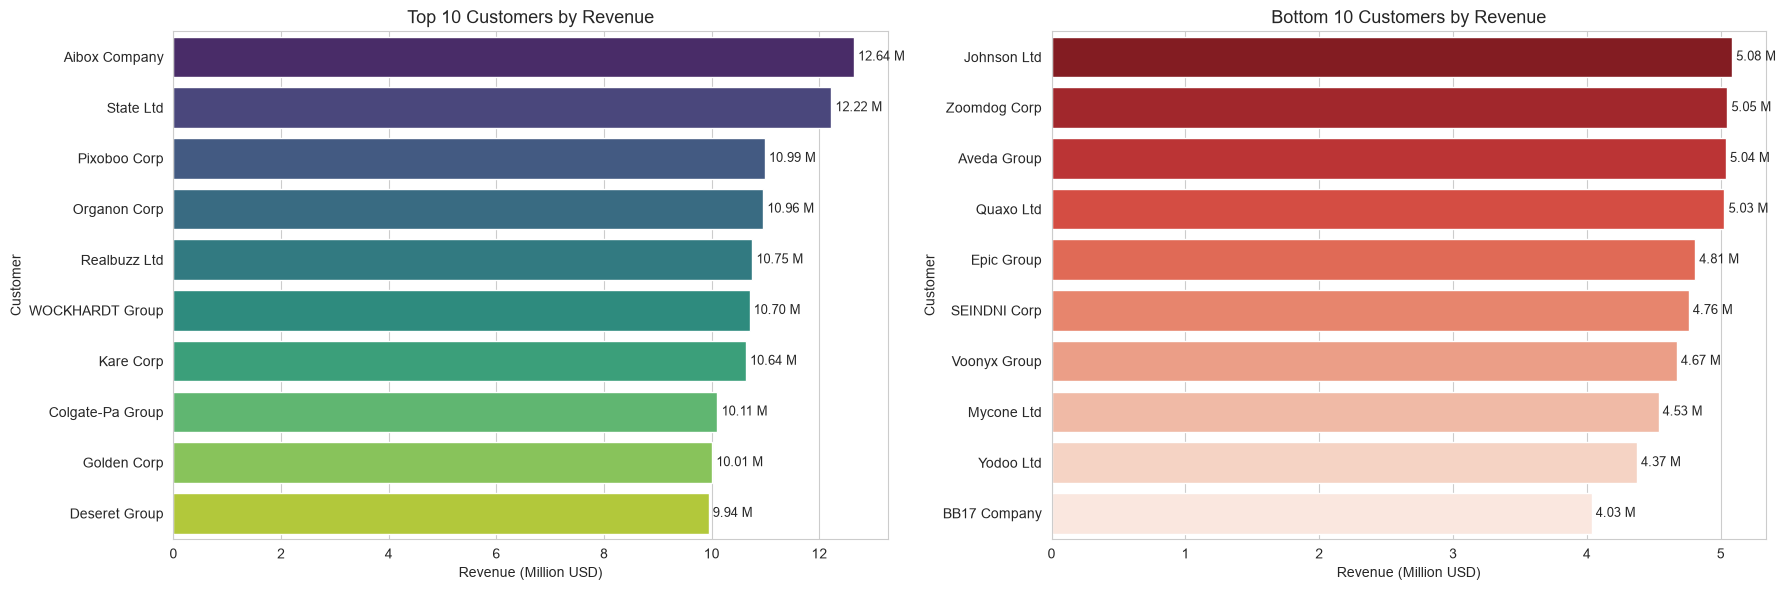

In [56]:
# Top & Bottom 10 Customers by Revenue

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# -----------------------------------------
# Top 10 Customers by Revenue
# -----------------------------------------
top_customers = (
    df.groupby('customer_name')['revenue']
      .sum()
      .div(1_000_000)              # Convert to Millions
      .nlargest(10)
)

ax1 = sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    palette='viridis',
    ax=axes[0]
)

for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%.2f M',
        padding=3,
        fontsize=9
    )

ax1.set_title('Top 10 Customers by Revenue', fontsize=13)
ax1.set_xlabel('Revenue (Million USD)')
ax1.set_ylabel('Customer')


# -----------------------------------------
# Bottom 10 Customers by Revenue
# -----------------------------------------
bottom_customers = (
    df.groupby('customer_name')['revenue']
      .sum()
      .div(1_000_000)
      .nsmallest(10)
      .sort_values(ascending=False)   # Bottom 10 at top, Bottom 1 at bottom
)

ax2 = sns.barplot(
    x=bottom_customers.values,
    y=bottom_customers.index,
    palette='Reds_r',
    ax=axes[1]
)

for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt='%.2f M',
        padding=3,
        fontsize=9
    )

ax2.set_title('Bottom 10 Customers by Revenue', fontsize=13)
ax2.set_xlabel('Revenue (Million USD)')
ax2.set_ylabel('Customer')

plt.tight_layout()
plt.show()

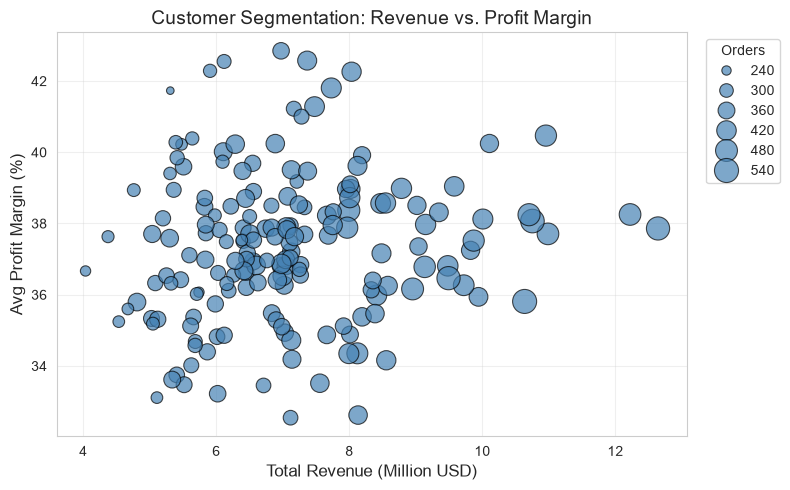

In [57]:
# Customer Segmentation: Revenue vs Profit Margin 

customer_seg = (
    df.groupby('customer_name')
      .agg(
          revenue=('revenue', 'sum'),
          profit_margin=('profit_margin_%', 'mean'),
          orders=('order_number', 'count')
      )
      .reset_index()
)

customer_seg['revenue'] = customer_seg['revenue'] / 1_000_000

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=customer_seg,
    x='revenue',
    y='profit_margin',
    size='orders',
    sizes=(30, 300),
    alpha=0.7,
    color='steelblue',
    edgecolor='black'
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin', fontsize=14)
plt.xlabel('Total Revenue (Million USD)', fontsize=12)
plt.ylabel('Avg Profit Margin (%)', fontsize=12)

plt.legend(title='Orders', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

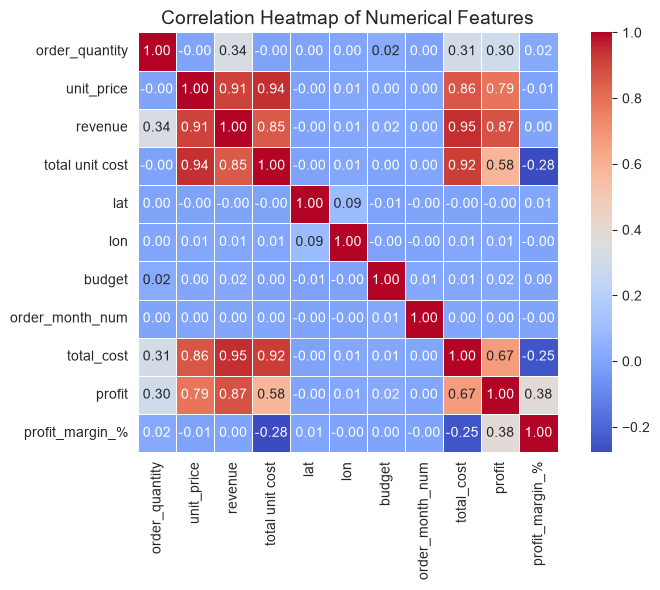

In [58]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))

# Select only numeric columns
corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14)

plt.tight_layout()
plt.show()